In [81]:
# Clean slate — frees memory and figures from any prior notebook run
# sharing this kernel. Safe on first run (no-op).
get_ipython().run_line_magic('reset', '-sf')
import gc
try:
    import matplotlib.pyplot as plt
    plt.close('all')
except ImportError:
    pass
gc.collect()

0

# Notebook 10 -- Left and Right Morphing Asymmetry

> **Supplementary §11**

The morphing shape modes are defined from unilateral data -- left and right sides analysed separately. This notebook compares left and right morphing scores to assess whether hawks morph their wings symmetrically or independently.

We use **major-axis (MA) regression** on left vs right scores: a slope near 1 and intercept near 0 indicates bilaterally symmetric control; deviations indicate independent left-right morphing. We examine symmetry across multiple flight contexts including flapping vs gliding, obstacle flights, and naive vs experienced hawks.

## Contents
1. [Setup and data loading](#setup)
2. [Reading the symmetry plots](#reading-the-symmetry-plots)
3. [Validating the symmetry assumption for modes 1-2](#validating-the-symmetry-assumption-for-modes-1-2)
4. [All non-obstacle flights](#all-non-obstacle-flights)
5. [Flapping (acceleration phase)](#flapping-phase-acceleration)
6. [Gliding (deceleration phase)](#gliding-phase-deceleration)
7. [Obstacle flights -- before and after](#obstacle-flights)
8. [Naive hawks](#naive-hawks)
9. [Time series of left/right scores](#time-series-of-left-and-right-scores)
10. [Summary](#summary)

In [82]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Andale Mono"
np.set_printoptions(suppress=True, precision=3)

from kinematic_morphospace import (
    filter_by, run_PCA,
    get_score_df,
)
from kinematic_morphospace.plotting import (
    prepare_left_right_comparison, plot_left_right,
    plot_left_right_just_two_stacked, plot_left_right_empty,
    plot_rotation_correction_comparison, plot_symmetry_validation,
    plot_score, plot_left_right_timeseries, print_symmetry_summary, save_figure,
)

# ── Configuration ──
CONFIG = {
    "alpha_all":        0.1,   # transparency: all non-obstacle flights (dense)
    "alpha_flapping":   0.5,   # flapping subsets
    "alpha_gliding":    0.5,   # gliding subsets
    "alpha_obstacle":   0.9,   # obstacle flights (sparse)
    "alpha_naive":      0.2,   # naive hawk subsets
    "bin_size":         0.15,  # horizontal-distance bin width (m)
    "fig_dir":          "../../figures/supplementary",
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data and Run PCA

We load the unilateral data and rerun PCA (trained on non-obstacle flights, projected onto all data) to obtain the scores needed for left/right comparison.

In [83]:
unilateral_data = np.load("../../data/unilateral/data.npy")
unilateral_frame_info_df = pd.read_csv("../../data/unilateral/frame_info.csv")

filt = filter_by(unilateral_frame_info_df, obstacle=0)
principal_components, scores, pca = run_PCA(unilateral_data[filt], unilateral_data)

# Create scores dataframe with binning
scores_df, _ = get_score_df(scores, unilateral_frame_info_df, size_bin=CONFIG["bin_size"])

# Load unrotated (pre-rotation-correction) scores for modes 1-2
# These avoid the circularity of rotation correction which assumes symmetry for modes 1-2
scores_df_norot = pd.read_csv("../../data/unilateral/scores_binned_no_correction.csv")

# ── Data summary ──
print(f"Total frames:  {scores.shape[0]:,}")
print(f"Modes:         {scores.shape[1]}")
print(f"Scores df:     {scores_df.shape}")
print()
n_obs    = filter_by(unilateral_frame_info_df, obstacle=0).sum()
n_obst   = filter_by(unilateral_frame_info_df, obstacle=1).sum()
n_naive  = filter_by(unilateral_frame_info_df, naive=1).sum()
n_exp    = filter_by(unilateral_frame_info_df, naive=0).sum()
print(f"Non-obstacle:  {n_obs:,}")
print(f"Obstacle:      {n_obst:,}")
print(f"Experienced:   {n_exp:,}")
print(f"Naive:         {n_naive:,}")

  Sign conventions applied: PC07 negated (positive = m-folded)
Total frames:  289,528
Modes:         12
Scores df:     (289528, 27)

Non-obstacle:  252,630
Obstacle:      36,898
Experienced:   95,498
Naive:         194,030


### Reading the Symmetry Plots

Each panel shows a scatter plot of right-side scores (x-axis) against left-side scores (y-axis) for one morphing mode. Two reference lines are drawn:

- **Grey solid line (x = y):** line of perfect bilateral symmetry
- **Black dotted line:** major-axis (MA) regression fit

The MA equation and percentage of variance along the major axis are annotated. If left and right scores are tightly coupled, the scatter lies along x = y with the MA slope near 1.0.

### Interpreting MA slope and intercept

- **Slope = 1.0:** Left and right sides change by equal amounts -- perfectly symmetric morphing.
- **Slope > 1.0:** The left side exaggerates the morphing movement relative to the right (or vice versa).
- **Intercept ≈ 0:** No systematic offset between sides.
- **Intercept ≠ 0:** A persistent asymmetry -- one side is consistently deflected relative to the other.


Number of frames: 131865
Number of flights: 1380


(<Figure size 200x200 with 1 Axes>,
 <Axes: xlabel='right scores', ylabel='left scores'>)

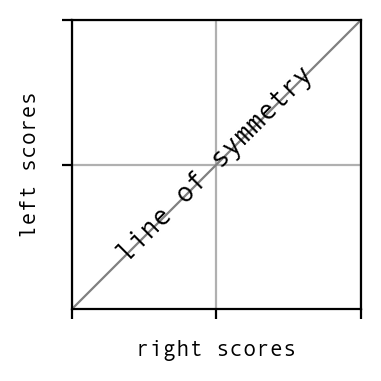

In [84]:
# Show an example empty plot to illustrate the layout
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df, obstacle=0
)
plot_left_right_empty(score_5, score_95, PC=0)

### Forced Symmetry in Modes 1 and 2

The rotation correction (§5) assumes that modes 1 and 2 are bilaterally symmetric, using them as the reference for estimating whole-body rotation. This means the corrected scores for these two modes have symmetry built in by construction.

To avoid this circularity, all figures below show modes 1-2 from uncorrected (pre-rotation) data and modes 3-9 from rotation-corrected data. Since the mode definitions (eigenvectors) are identical in both datasets (dot products ≥ 0.999; see §7), the scores are directly comparable -- only the underlying marker positions differ. This allows us to assess genuine bilateral coupling for modes 1-2 without the assumption confounding the result.

For the turning flights however, the banked turns in the flight make it difficult to assess how intrinsically symmetric modes 1-2 are. We therefore focus on modes 3-9 for the symmetry analyses, which are unaffected by the rotation correction and show more independent left-right variation. 

Number of frames: 41706
Number of flights: 839
Number of frames: 41706
Number of flights: 839
Number of frames: 18495
Number of flights: 254
Number of frames: 18495
Number of flights: 254
Saved: ../../figures/supplementary/S09_symmetry_validation.pdf


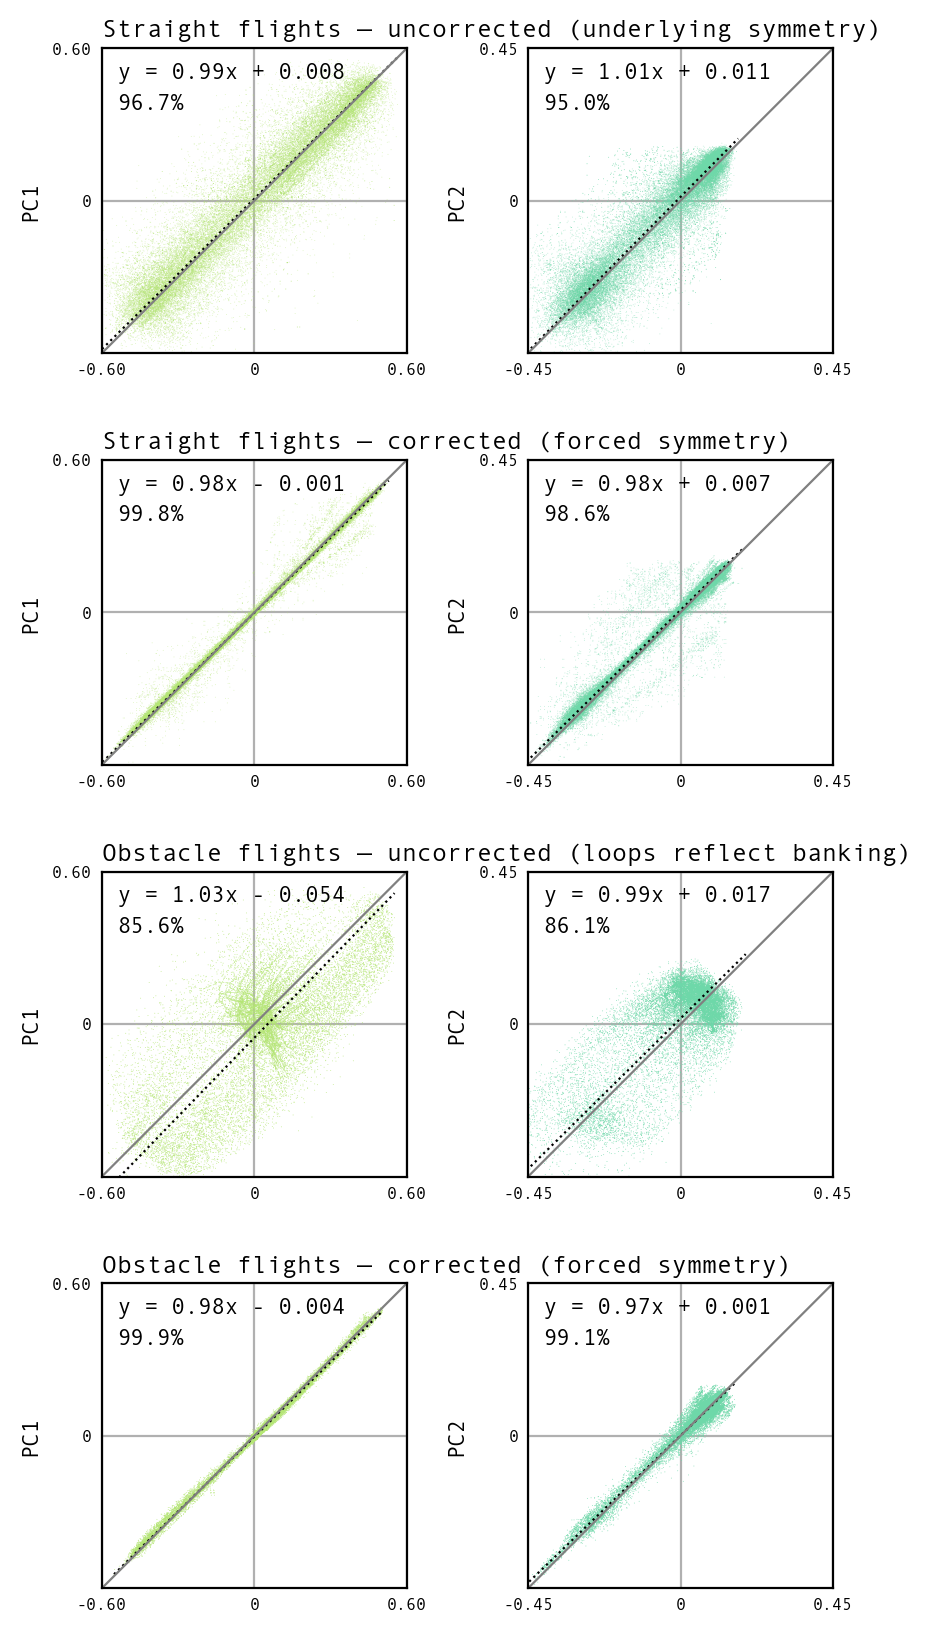

In [85]:
plt.close("all")
fig, axs = plot_symmetry_validation(
    scores_df, scores_df_norot,
    alpha_straight=CONFIG["alpha_flapping"],
    alpha_obstacle=CONFIG["alpha_obstacle"],
)
save_figure(fig, f'{CONFIG["fig_dir"]}/S09_symmetry_validation.pdf', rasterize=True)

**Interpretation.** The four rows compare uncorrected and corrected scores for modes 1–2 across straight and obstacle flights:

- **Straight flights -- uncorrected:** Modes 1 and 2 sit tightly along the line of symmetry even without rotation correction, confirming that wing lifting and wing spreading are genuinely bilaterally symmetric movements.

- **Straight flights -- corrected:** The rotation correction produces near-perfect symmetry (variance along the major axis approaches 100%). This is expected since there is little rotation to remove in straight flight.

- **Obstacle flights -- uncorrected:** The characteristic "looped" pattern appears: the scatter traces elliptical paths around the diagonal rather than diverging from it. This looping is the signature of whole-body roll and yaw being projected onto the left-right score axes -- a symmetric wing movement viewed from a banking body looks transiently asymmetric. Crucially, the loops are centred on the line of symmetry, not offset from it.

- **Obstacle flights -- corrected:** Despite strong banking rotations during turning flight, the corrected scores show tight bilateral coupling without the looping pattern. The rotation correction successfully removes the apparent asymmetry caused by whole-body rotation.

The high genuine symmetry (>97%) in uncorrected data **validates the assumption** underlying the rotation correction: wing lifting and spreading are bilaterally coupled movements. The looping in obstacle flights is entirely attributable to whole-body rotation, not asymmetric morphing -- consistent with the helicopter-like steering mechanism (Ros et al., 2011).

In all figures below, modes 1–2 use uncorrected scores (indicated by a dotted box) to show genuine bilateral coupling, while modes 3–9 use rotation-corrected scores to separate morphing from roll and yaw.

## All Non-Obstacle Flights

We first examine left/right symmetry across all non-obstacle flights from all hawks. This provides a baseline view of bilateral coupling. We expect strong bilateral symmetry in the dominant planform modes (1-4), with progressively more independence in higher modes that capture finer adjustments.

Number of frames: 131865
Number of flights: 1380

--- All non-obstacle flights ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     0.985    -0.0035   95.6%  strong
  PC02     0.980     0.0067   95.0%  strong
  PC03     0.991     0.0023   96.0%  strong
  PC04     0.972    -0.0005   89.3%  strong
  PC05     0.976     0.0028   84.2%  strong
  PC06     1.068    -0.0047   69.2%  moderate
  PC07     0.699    -0.0026   69.4%  weak
  PC08     1.078     0.0043   63.7%  moderate
  PC09     0.723     0.0017   71.2%  weak
  PC10     0.798     0.0010   68.3%  weak
  PC11     0.956     0.0022   76.3%  strong
  PC12     0.762    -0.0004   74.1%  weak
Saved: ../../figures/supplementary/S09_symmetry_all_nonobstacle.pdf


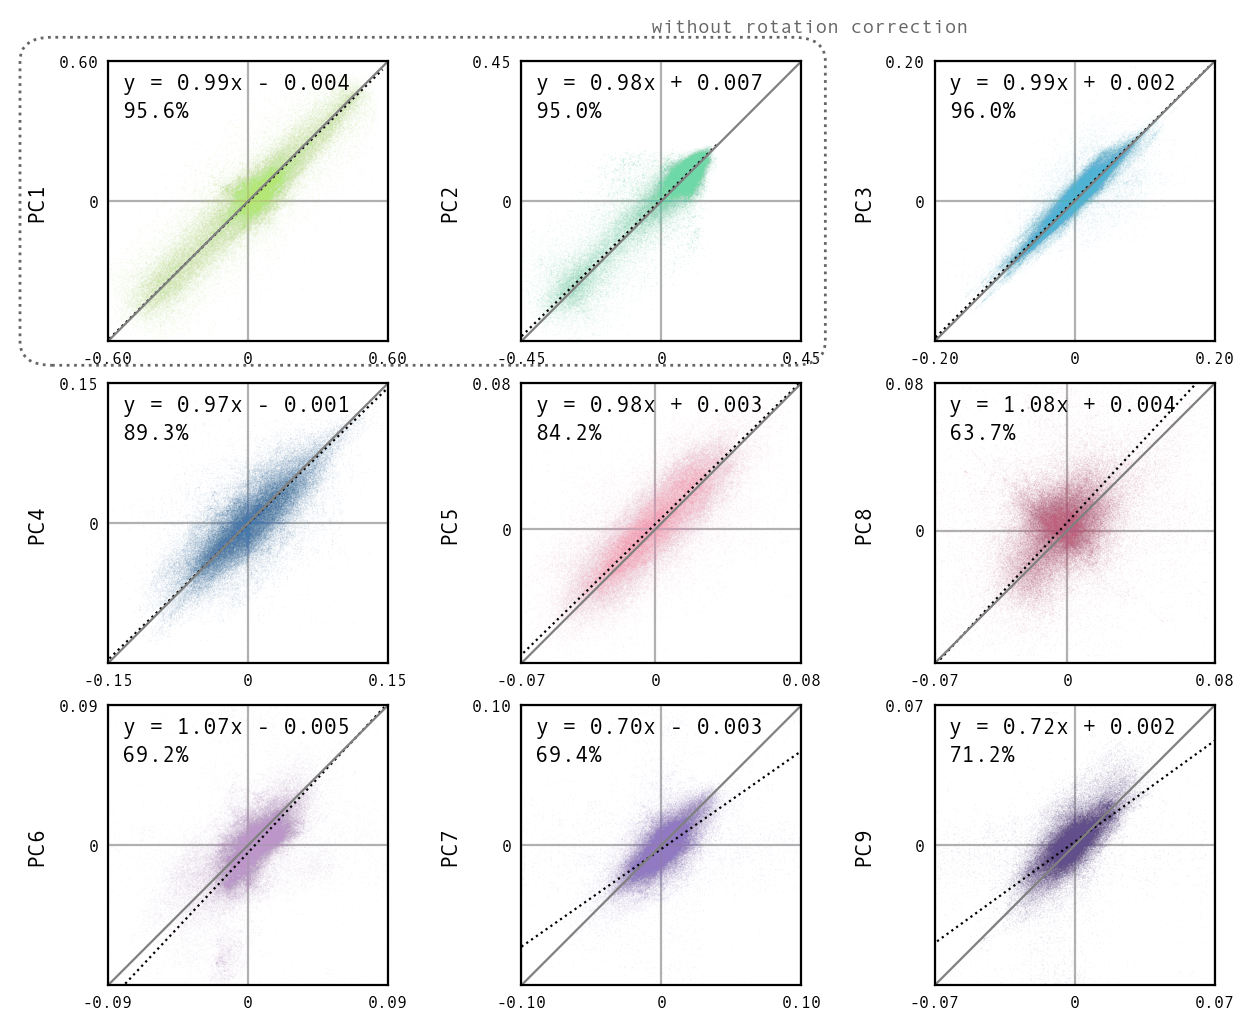

In [86]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df, scores_df_norot=scores_df_norot, obstacle=0
)
print_symmetry_summary(left_right_scores, label="All non-obstacle flights")
fig, axs = plot_left_right(left_right_scores, score_5, score_95,
                           alpha=CONFIG["alpha_all"], 
                           highlight_unrotated=True)
save_figure(fig, f'{CONFIG["fig_dir"]}/S09_symmetry_all_nonobstacle.pdf', rasterize=True)

**Interpretation.** The baseline confirms that the major planform modes (1-4) show MA slopes close to 1.0 with near-zero intercepts, indicating strong bilateral coupling during straight flight. Higher modes show progressively weaker coupling -- the scatter broadens and slopes deviate further from unity -- consistent with these modes capturing finer, less coordinated adjustments. This baseline establishes the reference against which we compare specific flight phases below.

## Flapping Phase (Acceleration)

During the first half of 9 m and 12 m flights, hawks are actively flapping to gain speed. We expect the tightest bilateral coupling here: coordinated wing beats require symmetric morphing to produce balanced thrust. Any systematic left-right differences during flapping would suggest asymmetric force production.

Experienced hawks only (excluding naive flights).

Number of frames: 10839
Number of flights: 233

--- Flapping -- experienced ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     1.007    -0.0148   98.9%  strong
  PC02     1.029     0.0096   97.2%  strong
  PC03     1.067     0.0054   96.5%  moderate
  PC04     1.168     0.0007   83.3%  weak
  PC05     1.027     0.0016   89.5%  strong
  PC06     1.234    -0.0013   92.1%  weak
  PC07     0.972     0.0024   90.4%  strong
  PC08     0.858    -0.0006   89.9%  moderate
  PC09     1.290     0.0039   84.7%  weak
  PC10     1.171    -0.0012   83.1%  weak
  PC11     0.925     0.0016   89.1%  moderate
  PC12     0.990    -0.0005   88.7%  strong
Saved: ../../figures/supplementary/S09_symmetry_flapping_experienced.pdf


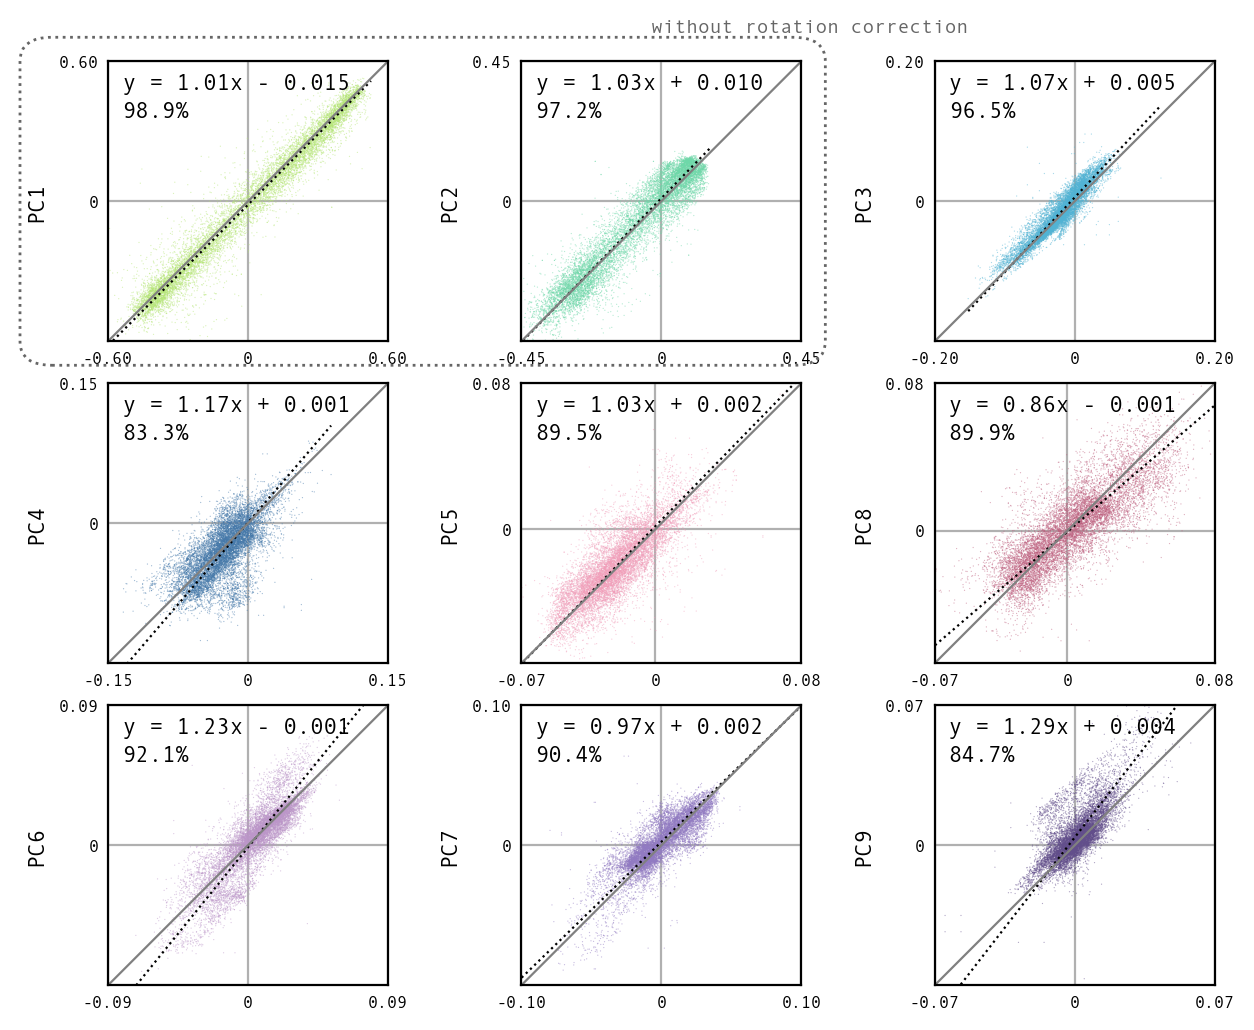

In [87]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df,
    scores_df_norot=scores_df_norot,
    obstacle=0,
    naive=0,
    perchDist=["9", "12"],
    horzdist="first_half",
)
print_symmetry_summary(left_right_scores, label="Flapping -- experienced")
fig, axs = plot_left_right(left_right_scores, score_5, score_95,
                           alpha=CONFIG["alpha_flapping"], 
                           highlight_unrotated=True,
                           point_size=0.2)
save_figure(fig, f'{CONFIG["fig_dir"]}/S09_symmetry_flapping_experienced.pdf', rasterize=True)

**Interpretation.** As expected, flapping shows the tightest bilateral coupling of any flight phase. The dominant modes maintain slopes very close to 1.0 and intercepts near zero, confirming that active wingbeats are highly symmetric. Even the mid-range modes (3-6) show tighter coupling than in the all-flights baseline, consistent with the aerodynamic demands of thrust production requiring coordinated bilateral morphing.

## Gliding Phase (Deceleration)

During the second half of 9 m and 12 m flights, hawks transition to gliding and decelerating as they approach the perch. We expect greater left-right independence than during flapping: fine-tuned aerodynamic adjustments for the approach do not require strict bilateral symmetry, and subtle corrections for crosswinds or landing angle may be asymmetric.

Experienced hawks only.

Number of frames: 15840
Number of flights: 229

--- Gliding -- experienced ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     0.969     0.0128   91.3%  strong
  PC02     1.013    -0.0056   89.0%  strong
  PC03     0.950    -0.0012   98.3%  moderate
  PC04     0.918    -0.0009   77.7%  moderate
  PC05     0.992    -0.0005   88.2%  strong
  PC06     0.791     0.0018   71.2%  weak
  PC07     0.813    -0.0011   73.6%  weak
  PC08     0.913    -0.0004   78.3%  moderate
  PC09     0.830     0.0011   75.0%  weak
  PC10     0.970    -0.0006   80.9%  strong
  PC11     1.237     0.0021   88.4%  weak
  PC12     1.230     0.0024   82.6%  weak
Saved: ../../figures/supplementary/S09_symmetry_gliding_experienced.pdf


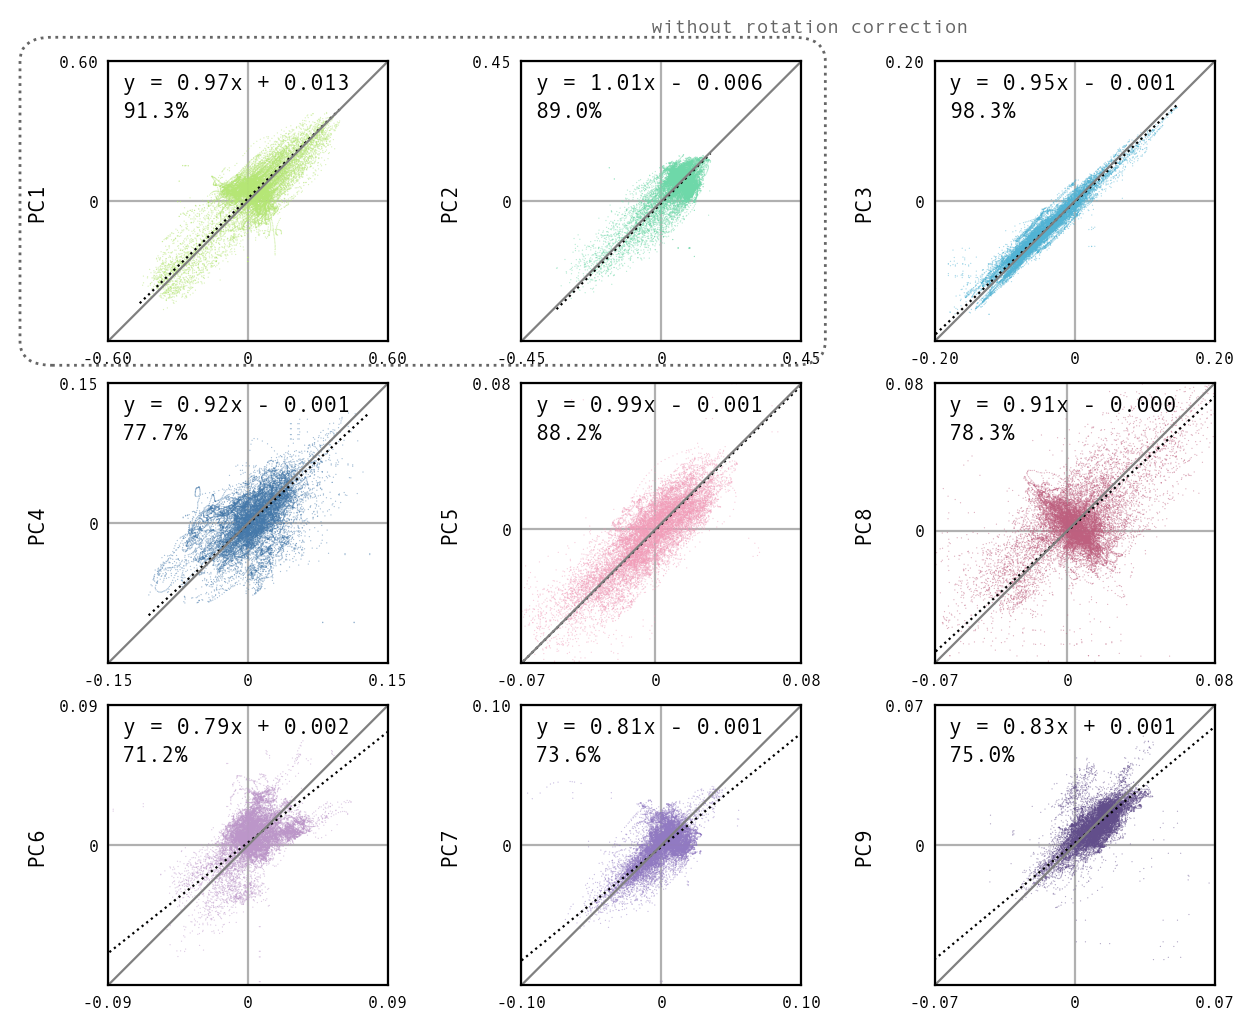

In [88]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df,
    scores_df_norot=scores_df_norot,
    obstacle=0,
    naive=0,
    perchDist=["9", "12"],
    horzdist="second_half",
)
print_symmetry_summary(left_right_scores, label="Gliding -- experienced")
fig, axs = plot_left_right(left_right_scores, score_5, score_95,
                           alpha=CONFIG["alpha_gliding"], 
                           highlight_unrotated=True,
                           point_size=0.2)
save_figure(fig, f'{CONFIG["fig_dir"]}/S09_symmetry_gliding_experienced.pdf', rasterize=True)

**Interpretation.** Compared to flapping, the gliding phase shows increased left-right independence. Hand-wing adjustments and tail lowering (collective pitch) exhibit wider scatter and slopes further from unity, consistent with fine-tuned aerodynamic control where each side can be adjusted semi-independently. The dominant modes (1-2) remain tightly coupled, but modes 3-5 show notably looser bilateral coordination than during flapping -- the hawks maintain symmetric gross posture while allowing independent fine control.

## Obstacle Flights

Obstacle flights force asymmetric manoeuvres as the hawk banks around the obstacle. We separate the approach (before the obstacle) from the recovery (after), as these phases place different aerodynamic demands on the wings and tail.

### Before the Obstacle

The hawk is approaching the obstacle and preparing to bank. We expect wings to be pitched more negatively (anticipatory posture) and the tail to become more spread and asymmetric as the hawk sets up for the turn. Experienced hawks, 9 m flights only.

Number of frames: 8157
Number of flights: 236

--- Obstacle -- before ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     0.978    -0.1110   89.4%  strong
  PC02     1.021     0.0217   85.2%  strong
  PC03     1.150     0.0059   95.9%  moderate
  PC04     1.262     0.0117   86.7%  weak
  PC05     1.170     0.0038   85.2%  weak
  PC06     0.967     0.0038   91.4%  strong
  PC07     0.967     0.0025   90.5%  strong
  PC08     0.832    -0.0013   85.3%  weak
  PC09     1.032     0.0016   85.4%  strong
  PC10     0.978    -0.0010   81.3%  strong
  PC11     0.999    -0.0002   94.2%  strong
  PC12     0.802    -0.0017   79.0%  weak
Saved: ../../figures/supplementary/S09_symmetry_obstacle_before.pdf


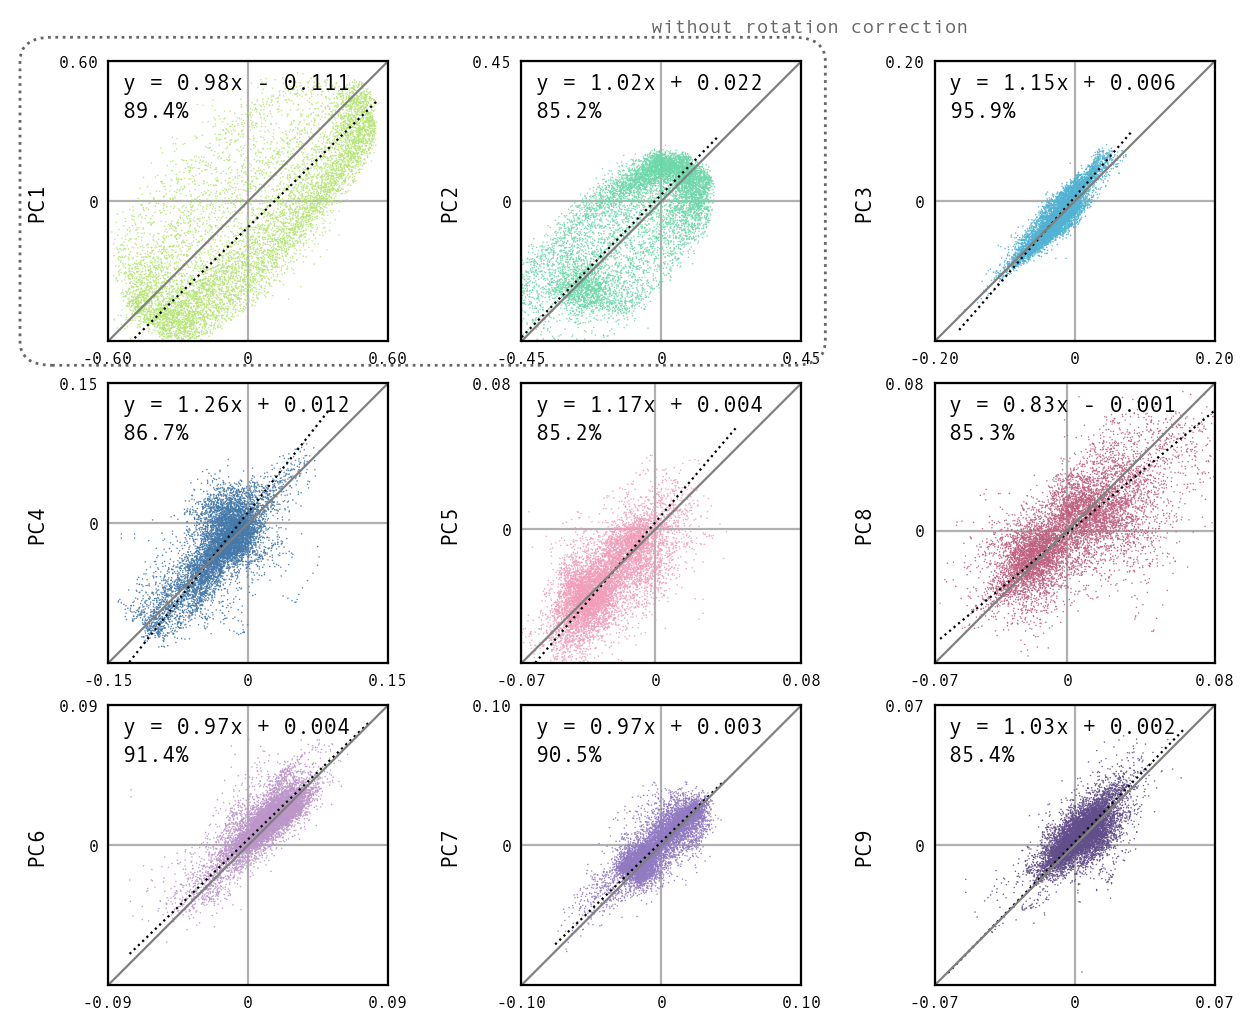

In [89]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df,
    scores_df_norot=scores_df_norot,
    obstacle=1,
    perchDist=["9"],
    horzdist="first_half",
)
print_symmetry_summary(left_right_scores, label="Obstacle -- before")
fig, axs = plot_left_right(left_right_scores, score_5, score_95, 
                           alpha=CONFIG["alpha_obstacle"], highlight_unrotated=True,
                           point_size=0.3)
save_figure(fig, f'{CONFIG["fig_dir"]}/S09_symmetry_obstacle_before.pdf', rasterize=True)

**Interpretation.** The approach phase shows the onset of asymmetry. Tail-related modes show wider scatter and non-zero intercepts, indicating that the tail is used asymmetrically as the hawk prepares the banked turn. Wing modes remain more coupled than tail modes, suggesting the wings maintain relatively coordinated posture while the tail initiates directional control.

### After the Obstacle

Post-obstacle, the hawk has completed the banked turn and is stabilising toward the perch. We expect yaw to be stabilised and roll decreased, but greater asymmetry in hand-wing shape changes and tail spreading. Anti-symmetric collective pitching (one side pitched up, the other down) would indicate tail banking for yaw stabilisation -- a "helicopter-like" steering mechanism (Ros et al., 2011).

Number of frames: 10338
Number of flights: 244

--- Obstacle -- after ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     0.991    -0.0070   73.3%  strong
  PC02     0.727     0.0262   63.5%  weak
  PC03     0.992     0.0036   96.2%  strong
  PC04     1.293     0.0053   69.9%  weak
  PC05     1.023     0.0018   87.9%  strong
  PC06     0.637     0.0016   60.4%  weak
  PC07     1.976    -0.0053   60.3%  weak
  PC08     0.694     0.0031   61.5%  weak
  PC09     1.221    -0.0039   79.3%  weak
  PC10     1.098    -0.0001   82.4%  moderate
  PC11     1.052     0.0001   85.6%  moderate
  PC12     2.224     0.0017   77.1%  weak
Saved: ../../figures/supplementary/S09_symmetry_obstacle_after.pdf


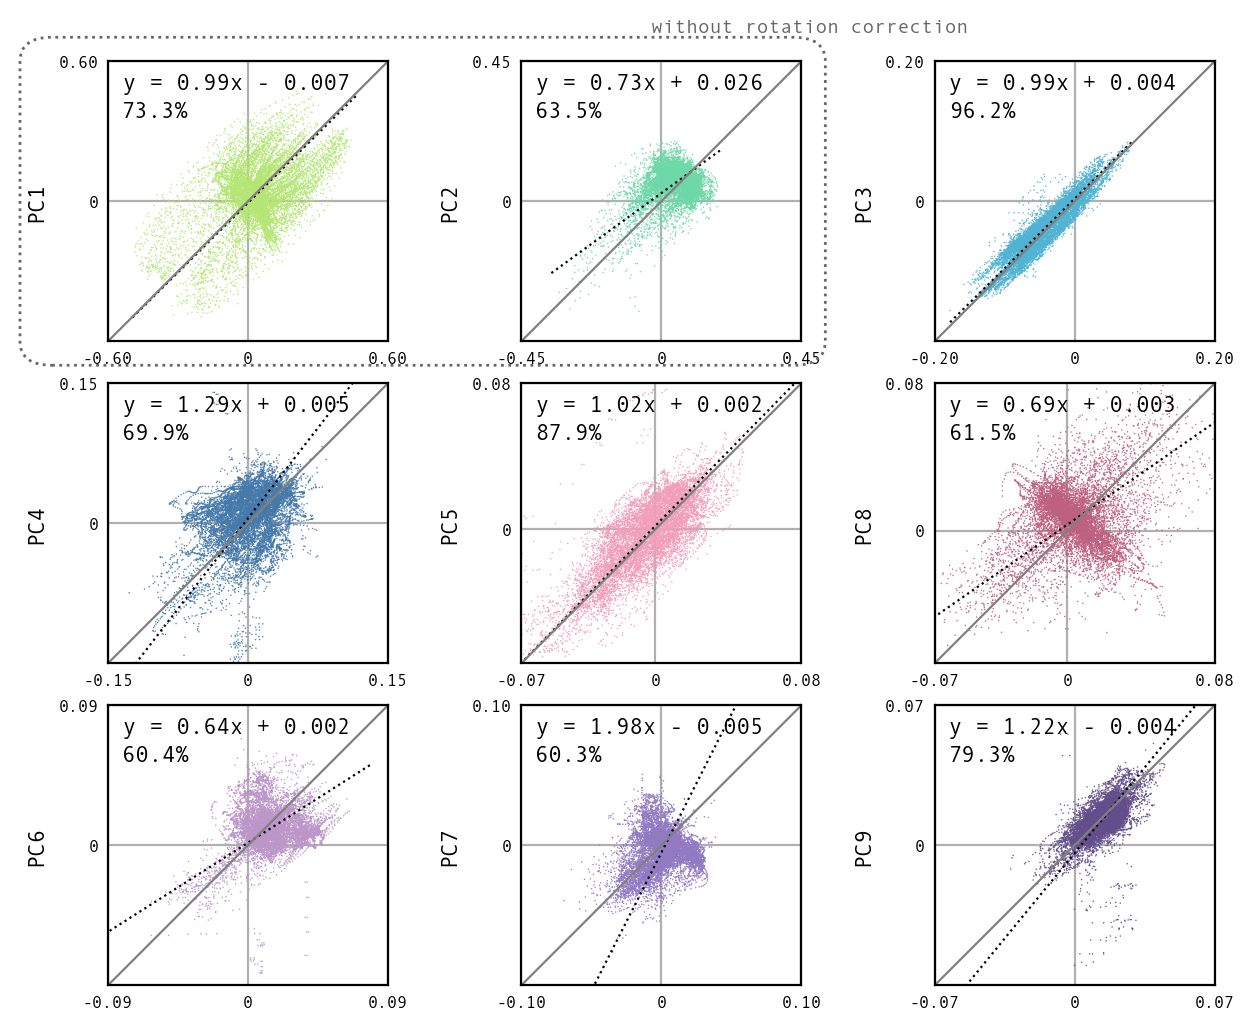

In [90]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df,
    scores_df_norot=scores_df_norot,
    obstacle=1,
    perchDist=["9"],
    horzdist="second_half",
)
print_symmetry_summary(left_right_scores, label="Obstacle -- after")
fig, axs = plot_left_right(left_right_scores, score_5, score_95, 
                           alpha=CONFIG["alpha_obstacle"],
                           highlight_unrotated=True,
                           point_size=0.3)
save_figure(fig, f'{CONFIG["fig_dir"]}/S09_symmetry_obstacle_after.pdf', rasterize=True)

**Interpretation.** The post-obstacle phase shows the clearest asymmetric signatures. Hand-wing shape changes and tail spreading exhibit greater left-right independence, with anti-symmetric collective pitching (negative MA slope or large intercept offset in the relevant tail modes) indicating that the tail is banked -- one side pitched up while the other is pitched down. This is consistent with tail banking for yaw stabilisation as the hawk steers back toward the perch after the turn.

## Naive Hawks

Naive (first-year) hawks have less flight experience. We expect juveniles to show more left-right independent morphing compared to experienced hawks, suggesting that bilateral coordination improves with practice. The difference should be most pronounced in modes 3-5 (sweep, tail spread, counter-pitching), where experienced hawks achieve tighter bilateral coupling.

### Naive -- Flapping Phase

Number of frames: 35550
Number of flights: 768

--- Naive -- flapping ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     0.983     0.0125   95.9%  strong
  PC02     1.008     0.0112   94.1%  strong
  PC03     0.971     0.0054   91.4%  strong
  PC04     0.988     0.0027   84.5%  strong
  PC05     0.946     0.0025   75.5%  moderate
  PC06     1.152    -0.0055   67.4%  weak
  PC07     0.702    -0.0019   65.9%  weak
  PC08     1.518     0.0003   66.0%  weak
  PC09     0.608    -0.0004   67.9%  weak
  PC10     0.753     0.0016   68.7%  weak
  PC11     0.793     0.0015   68.5%  weak
  PC12     0.637    -0.0002   74.8%  weak
Saved: ../../figures/supplementary/S09_symmetry_naive_flapping.pdf


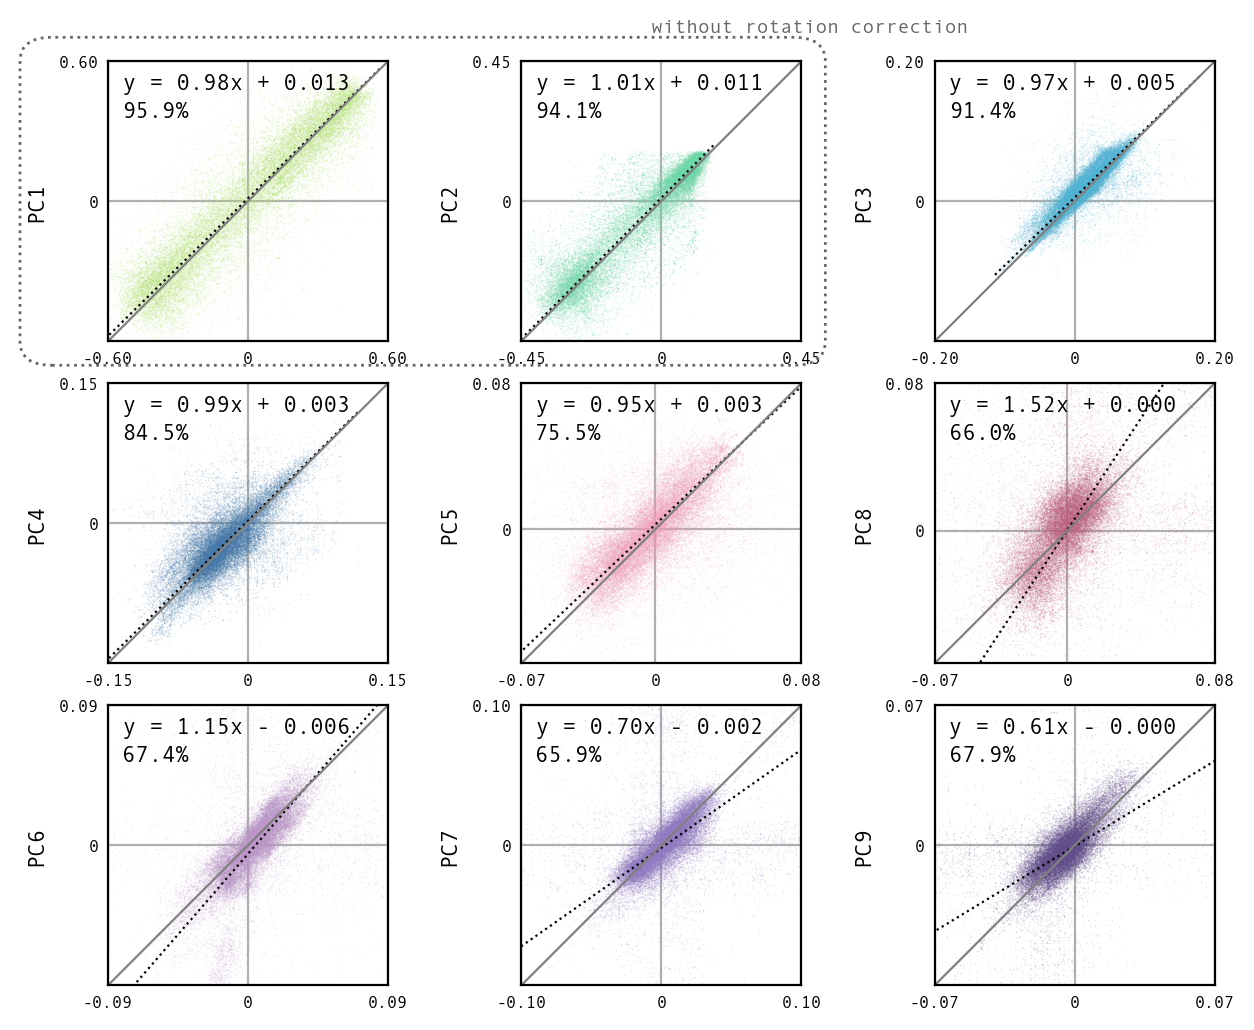

In [91]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df,
    scores_df_norot=scores_df_norot,
    obstacle=0,
    naive=1,
    horzdist="first_half",
)
print_symmetry_summary(left_right_scores, label="Naive -- flapping")
fig, axs = plot_left_right(left_right_scores, score_5, score_95,
                           alpha=CONFIG["alpha_naive"], highlight_unrotated=True,
                           point_size=0.2)
save_figure(fig, f'{CONFIG["fig_dir"]}/S09_symmetry_naive_flapping.pdf', rasterize=True)

**Interpretation.** Naive hawks show looser bilateral coupling even during flapping -- the phase where experienced hawks are most tightly coupled. Modes 3-5 in particular exhibit wider scatter and slopes further from unity than their experienced counterparts, suggesting that juveniles have not yet developed the tight bilateral coordination seen in experienced birds. The dominant modes (1-2) remain reasonably coupled, indicating that the gross wing lifting and spreading movements are symmetric even in inexperienced hawks.

### Naive -- Gliding Phase

Number of frames: 34818
Number of flights: 560

--- Naive -- gliding ---
  Mode     Slope  Intercept   Var %  Coupling
  PC01     0.962    -0.0085   92.7%  strong
  PC02     0.904     0.0133   84.0%  moderate
  PC03     1.012     0.0013   95.7%  strong
  PC04     0.960     0.0016   88.9%  strong
  PC05     1.027     0.0018   85.9%  strong
  PC06     1.861    -0.0108   70.1%  weak
  PC07     0.550    -0.0036   67.8%  weak
  PC08    -0.478    -0.0027   53.9%  weak
  PC09     0.697    -0.0005   70.1%  weak
  PC10     0.614     0.0034   68.2%  weak
  PC11     0.600     0.0016   67.8%  weak
  PC12     0.699     0.0002   69.9%  weak
Saved: ../../figures/supplementary/S09_symmetry_naive_gliding.pdf


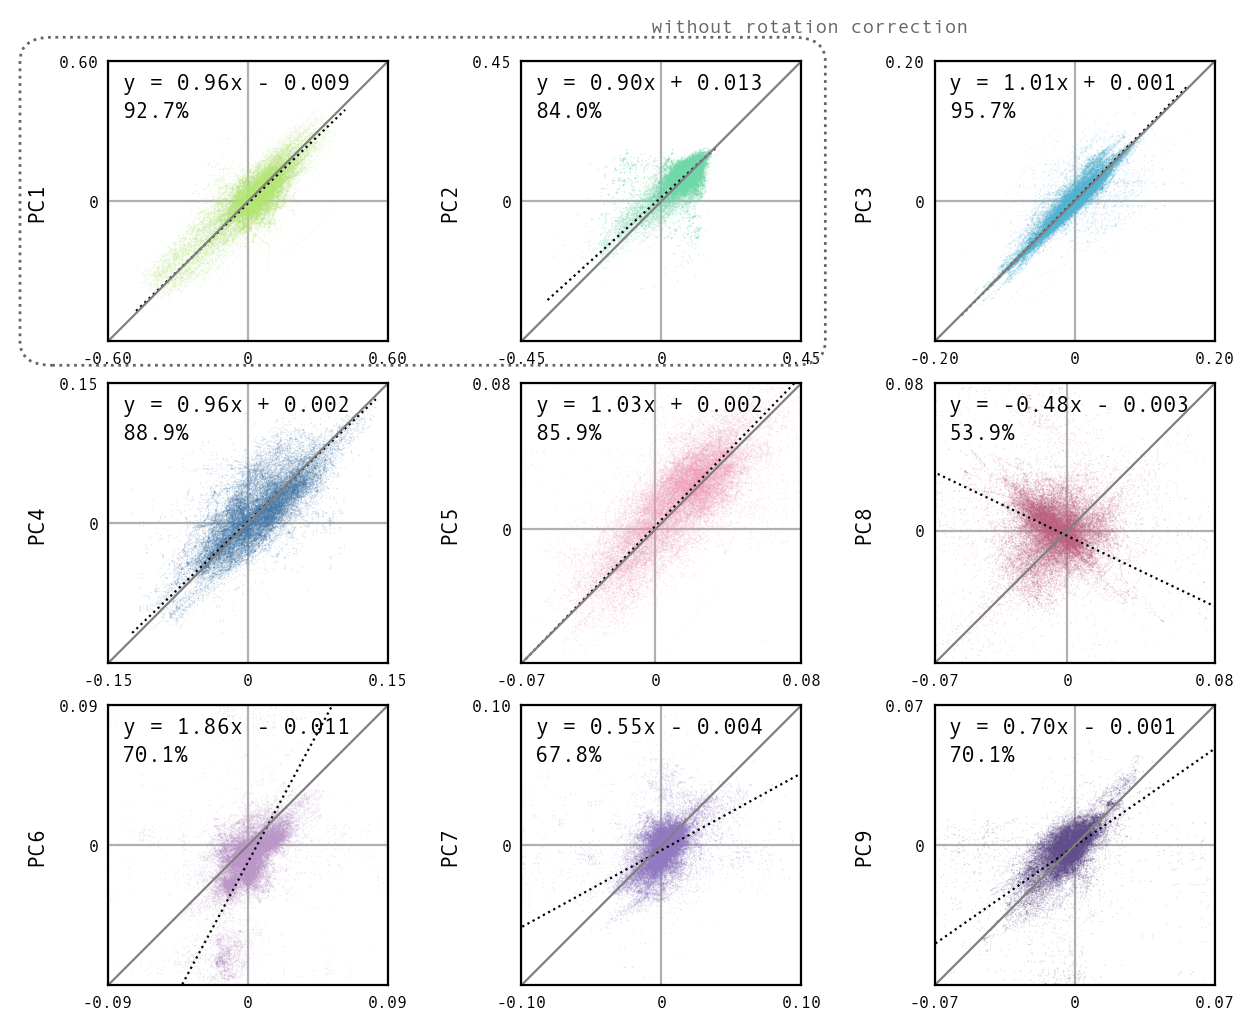

In [92]:
plt.close("all")
left_right_scores, score_5, score_95 = prepare_left_right_comparison(
    scores_df,
    scores_df_norot=scores_df_norot,
    obstacle=0,
    naive=1,
    perchDist=["9", "12"],
    horzdist="second_half",
)
print_symmetry_summary(left_right_scores, label="Naive -- gliding")
fig, axs = plot_left_right(left_right_scores, score_5, score_95,
                           alpha=CONFIG["alpha_naive"], highlight_unrotated=True,
                           point_size=0.2)
save_figure(fig, f'{CONFIG["fig_dir"]}/S09_symmetry_naive_gliding.pdf', rasterize=True)

**Interpretation.** Naive hawks during gliding show the widest scatter and most left-right independence of any condition examined. Compared to experienced hawks gliding (which already showed more independence than flapping), juveniles exhibit even weaker bilateral coupling across most modes. This compounds the experience effect with the phase effect: both inexperience and the aerodynamic demands of deceleration contribute to reduced bilateral coordination.

## Time Series of Left and Right Scores

To see how left-right asymmetry manifests over the course of a flight, we plot the left and right scores separately against horizontal distance for a single hawk (Toothless) and for tail spreading(PC04) and tail lifting (PC05). Comparing straight flights with turning flights reveals how turns introduce temporal asymmetry: in a straight flight the left and right traces should overlap, while turns should produce visible separation where one side is deflected relative to the other.

Note: this is a single-hawk, single-mode illustration. The MA regression analysis above provides the population-level results and statistics; this time series shows what asymmetry *looks like* within an averaged flight by an individual.

Saved: ../../figures/supplementary/S09_symmetry_timeseries_PC04_Toothless.pdf


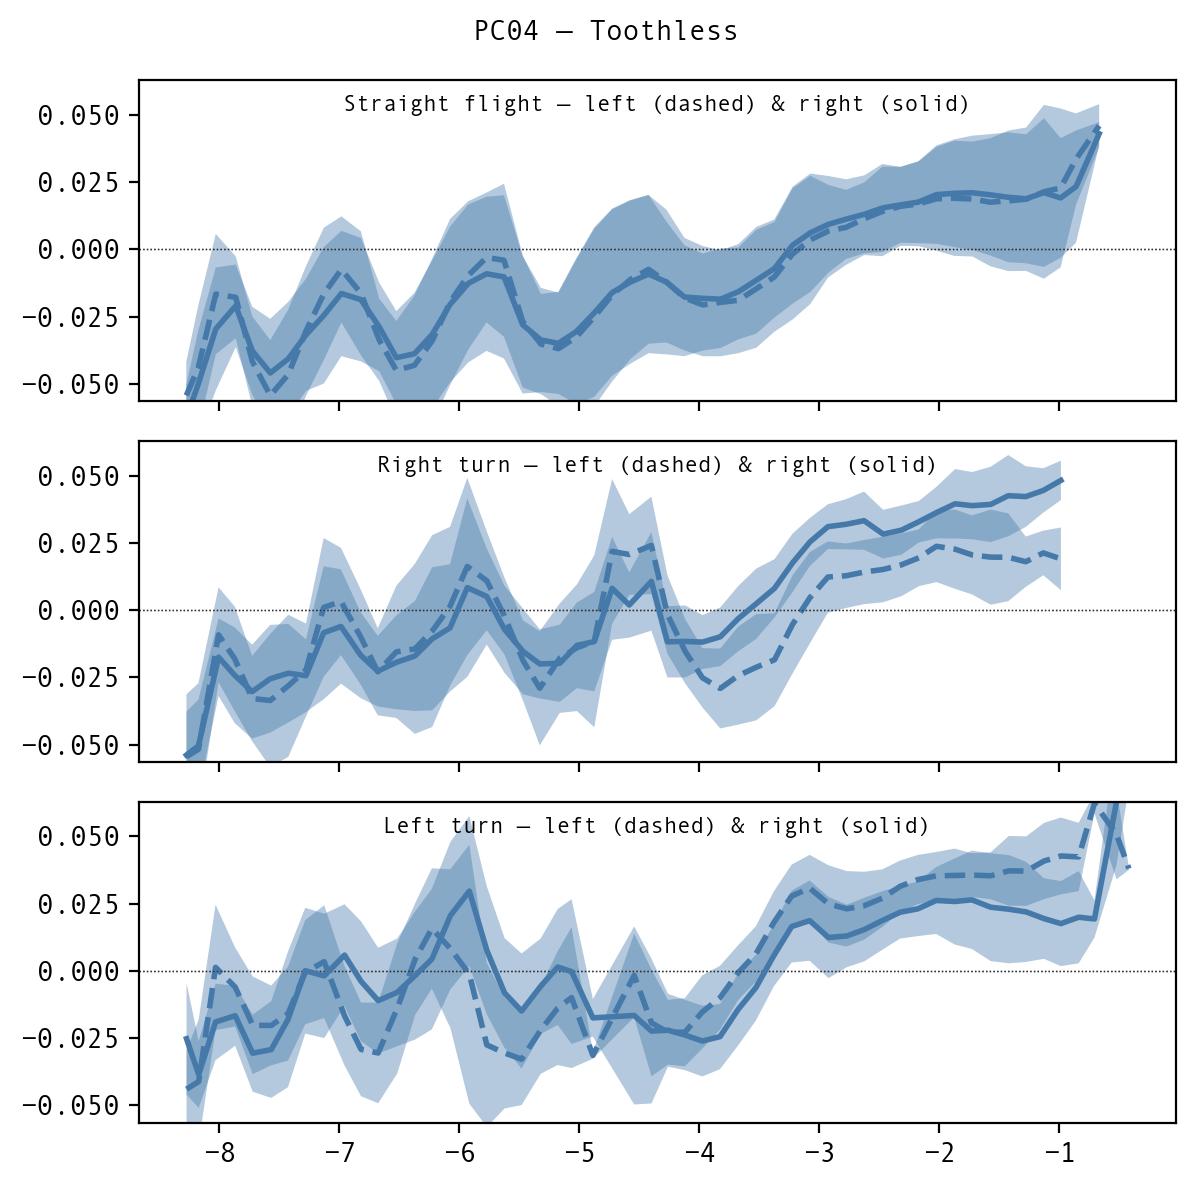

In [93]:
which_PC = "PC04"
which_hawk = "Toothless"

fig, axes = plot_left_right_timeseries(scores_df, which_PC, which_hawk)
save_figure(fig, f'{CONFIG["fig_dir"]}/S09_symmetry_timeseries_{which_PC}_{which_hawk}.pdf')


**Interpretation.** In straight flight, the left and right PC04 traces largely overlap, confirming bilateral symmetry in tail spreading during non-manoeuvring flight. During turns, the traces separate: one side shows increased tail spread while the other decreases, producing the asymmetric tail posture that generates the yaw moment needed for turning. The separation is most pronounced through the glide, consistent with the hawks recovering their heading after the turn to reach the perch. 

### PC08 -- tail banking

PC08 captures collective pitching of the tail. During obstacle flights the left and right sides diverge -- one side pitched up, the other down -- producing the anti-symmetric tail banking that stabilises yaw after the turn. Straight flights should remain overlapping.


Saved: ../../figures/supplementary/S09_symmetry_timeseries_PC08_Toothless.pdf


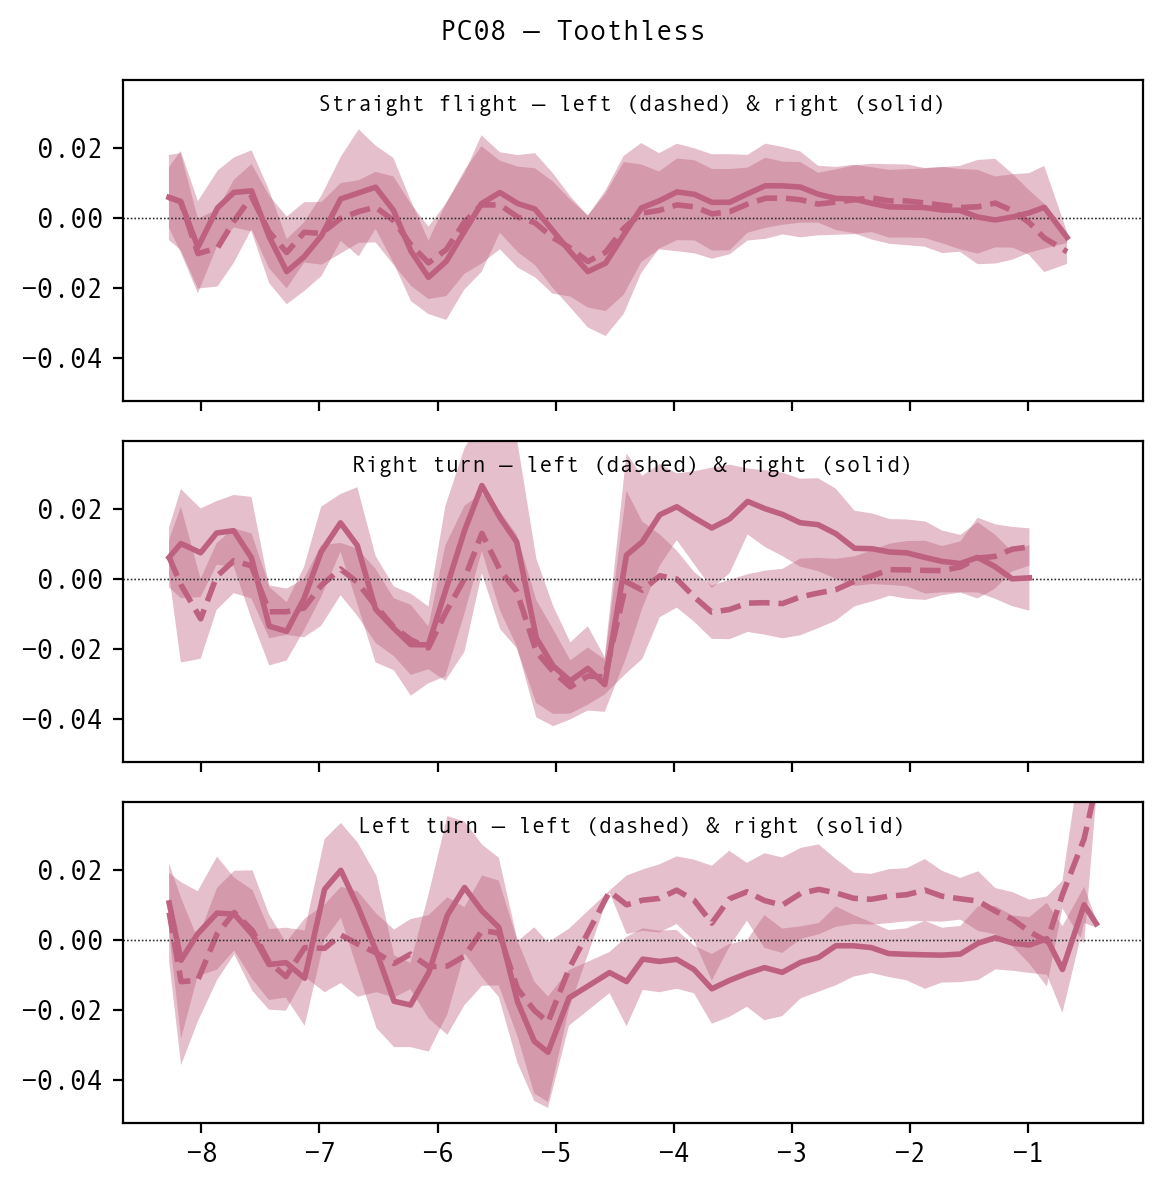

In [94]:
which_PC = "PC08"
which_hawk = "Toothless"

fig, axes = plot_left_right_timeseries(scores_df, which_PC, which_hawk)
save_figure(fig, f'{CONFIG["fig_dir"]}/S09_symmetry_timeseries_{which_PC}_{which_hawk}.pdf')


## Summary

Left-right morphing symmetry varies systematically across flight contexts:

- **Flapping (acceleration):** The tightest bilateral coupling of any condition. Modes 1-4 show MA slopes very close to 1.0, and even the mid-range modes (3-6) are more tightly coupled than in the all-flights baseline. Coordinated wing beats require symmetric morphing for balanced thrust.

- **Gliding (deceleration):** The dominant modes (1-2) remain tightly coupled, but modes 3-5 (sweep, tail spread, counter-pitching) show notably more left-right independence than during flapping. This is consistent with fine aerodynamic control during approach, where each side can be adjusted semi-independently.

- **Obstacle -- before:** Tail-related modes begin to show asymmetry as the hawk prepares the banked turn. Wing modes remain relatively coupled, suggesting the tail initiates directional control.

- **Obstacle -- after:** The clearest asymmetric signatures. Hand-wing shape changes and tail spreading show greater independence, with anti-symmetric collective pitching indicating tail banking for yaw stabilisation.

- **Naive vs experienced:** Juveniles show looser bilateral coupling than experienced hawks across most modes, particularly 3-5. The difference is present even during flapping, and compounds with the gliding-phase effect. This suggests bilateral coordination is a learned skill that improves with flight experience.

- **Time series:** Within individual flights, left-right separation during turns is spatially localised around the manoeuvre point and returns toward symmetry in straight segments.

- **Modes 1-2 validation:** Using uncorrected (pre-rotation) data, wing lifting and wing spreading are confirmed as genuinely bilaterally symmetric even during banked turns. The "looped" scatter pattern in obstacle flights is attributable to whole-body rotation, not asymmetric morphing -- consistent with the helicopter-like steering mechanism (Ros et al., 2011) and validating the rotation correction procedure.

---

## References

- Ros, I. G., Bassman, L. C., Badger, M. A., Pierson, A. N. & Biewener, A. A. (2011). Pigeons steer like helicopters and generate down- and upstroke lift during low speed turns. *Proceedings of the National Academy of Sciences*, 108, 19990-19995.